In [1]:
import cv2
import matplotlib.pyplot as plt

# Thresholding để phân đoạn ảnh

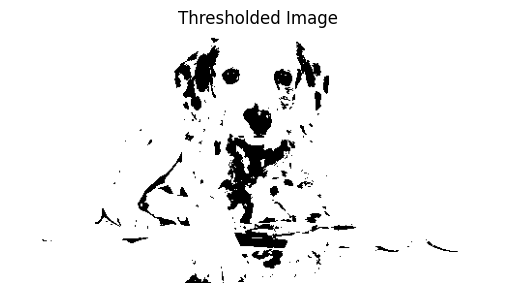

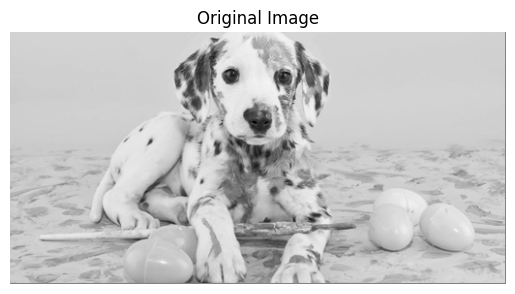

In [2]:
# Đọc ảnh ở dạng grayscale
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)

# Áp dụng threshold
ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Hiển thị kết quả
plt.imshow(thresh, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Otsu algorithm để phân đoạn ảnh vân tay

Optimal threshold: 163.0


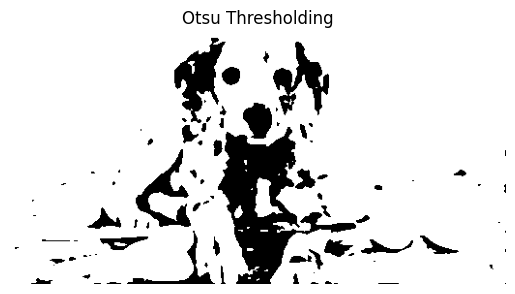

In [3]:
# Làm mịn
img_blur = cv2.GaussianBlur(img, (5, 5), 0)

# Otsu
ret, thresh_otsu = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Optimal threshold:", ret)
plt.imshow(thresh_otsu, cmap="gray")
plt.title("Otsu Thresholding")
plt.axis("off")
plt.show()

# Clustering techniques trong phân đoạn ảnh, K-mean clustering

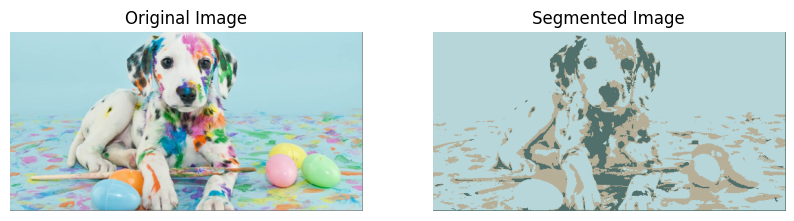

In [4]:
import numpy as np

# Đọc ảnh
img = cv2.imread("image.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape ảnh thành danh sách pixel
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Tiêu chí dừng
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Số cụm (K)
k = 3

# Áp dụng K-means
_, labels, centers = cv2.kmeans(
    pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS
)

# Chuyển centers về uint8
centers = np.uint8(centers)

# Gán lại màu cho từng pixel
segmented_data = centers[labels.flatten()]

# Reshape lại thành ảnh
segmented_image = segmented_data.reshape(img_rgb.shape)

# Hiển thị ảnh gốc và ảnh đã phân đoạn
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title("Segmented Image")
plt.axis("off")
plt.show()

# Sử dụng thuật toán Region growing

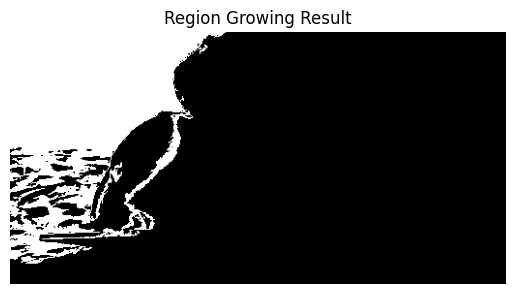

In [5]:
def region_growing(img, seed, threshold=5):
    h, w = img.shape
    segmented = np.zeros((h, w), np.uint8)

    # stack để duyệt (DFS)
    stack = [seed]
    seed_value = img[seed]

    while stack:
        x, y = stack.pop()

        if segmented[x, y] == 0:
            segmented[x, y] = 255

            # duyệt 8 hướng
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy

                    if 0 <= nx < h and 0 <= ny < w:
                        if segmented[nx, ny] == 0:
                            if abs(int(img[nx, ny]) - int(seed_value)) < threshold:
                                stack.append((nx, ny))

    return segmented


# ===== MAIN =====
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)

# chọn seed (tọa độ pixel)
seed_point = (100, 100)

result = region_growing(img, seed_point, threshold=10)

# Hiển thị kết quả
plt.imshow(result, cmap="gray")
plt.title("Region Growing Result")
plt.axis("off")
plt.show()

# Sử dụng thuật toán Slit and merge để phân đoạn ảnh

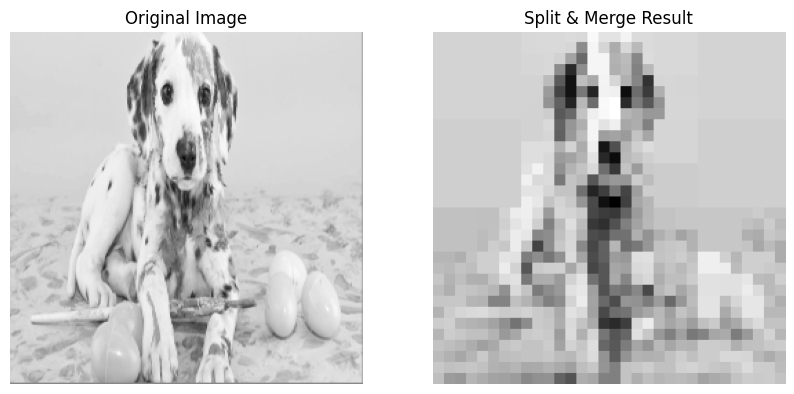

In [6]:
# Kiểm tra vùng có đồng nhất không
def is_homogeneous(region, threshold):
    return np.std(region) < threshold


# Split (chia ảnh theo quadtree)
def split(img, x, y, size, threshold, segments):
    region = img[x : x + size, y : y + size]

    if size <= 8 or is_homogeneous(region, threshold):
        segments.append((x, y, size))
        return

    half = size // 2

    split(img, x, y, half, threshold, segments)
    split(img, x, y + half, half, threshold, segments)
    split(img, x + half, y, half, threshold, segments)
    split(img, x + half, y + half, half, threshold, segments)


# Merge (đơn giản: tô màu trung bình)
def merge(img, segments):
    result = np.zeros_like(img)

    for x, y, size in segments:
        region = img[x : x + size, y : y + size]
        mean_val = np.mean(region)

        result[x : x + size, y : y + size] = mean_val

    return result


# ===== MAIN =====
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)

# resize về kích thước 2^n cho dễ chia
img = cv2.resize(img, (256, 256))

segments = []

# split
split(img, 0, 0, img.shape[0], threshold=10, segments=segments)

# merge
result = merge(img, segments)

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Split & Merge Result")
plt.axis("off")
plt.show()

# Phân đoạn ảnh với Edge-based segmentation

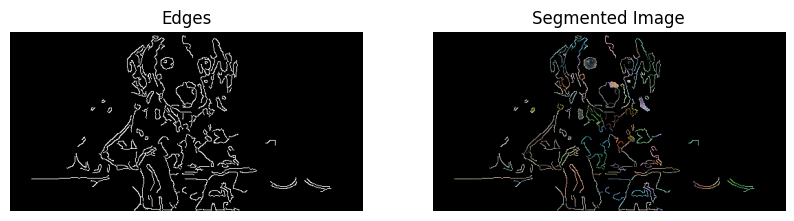

In [ ]:
img = cv2.imread("image.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 100, 200)

# Tìm contour
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Tạo mask
mask = np.zeros_like(gray)

# Vẽ vùng
cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)

# Áp dụng mask
segmented = cv2.bitwise_and(img, img, mask=mask)

# Hiển thị kết quả
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("Segmented Image")
plt.axis("off")
plt.show()